In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\LENOVO\Desktop\machine learning\100_days_of_ML\day_38_num+catagorical_both\train.csv', usecols=['Age', 'Fare', 'Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
x = df.drop(columns='Survived')
y = df['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 , random_state = 2)

In [8]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [9]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [10]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [18]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [19]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([17.  , 18.  , 36.  , 19.  , 21.  , 45.  , 16.  , 33.  , 28.  ,
       21.  , 27.  , 36.  , 39.  , 30.  , 31.  , 34.  , 21.  , 18.  ,
       28.  , 50.  , 70.  , 33.  , 26.  , 34.  , 34.  , 31.  , 52.  ,
       32.  , 47.  , 21.  ,  6.  , 22.  , 21.  , 22.  , 30.  ,  7.  ,
       39.  , 43.  , 35.  , 38.  , 64.  , 36.  , 29.  , 60.  , 22.  ,
       15.  , 16.  , 59.  , 47.  , 48.  , 17.  , 24.  , 47.  , 18.  ,
       40.  ,  4.  , 61.  , 51.  , 24.  , 52.  , 61.  , 22.  , 45.  ,
       16.  , 24.  , 36.  , 24.  , 36.  , 30.  , 30.  , 39.  , 22.  ,
       19.  , 49.  , 31.  , 40.  , 40.  , 50.  , 29.  , 52.  , 36.  ,
        0.83, 40.  , 19.  , 22.  , 40.  , 18.  ,  4.  , 30.  , 54.  ,
       20.  , 16.  , 26.  , 45.  , 28.  , 25.  , 34.  , 30.  , 39.  ,
       34.  , 43.  , 54.  , 25.  , 20.  , 38.  , 36.  , 19.  , 50.  ,
       40.  , 21.  , 30.  , 48.  , 32.  , 21.  , 33.  , 27.  , 34.  ,
       30.  , 21.  , 37.  , 20.  , 48.  , 36.  , 26.  , 36.  , 16.  ,
       28.5 ,  4.  ,

In [20]:
X_train['Age'].isnull().sum()

np.int64(148)

In [21]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,26.0
493,71.0,49.5042,71.0
527,NaN,221.7792,26.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15896\3805712594.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label = 'original' , hist = False)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15896\3805712594.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

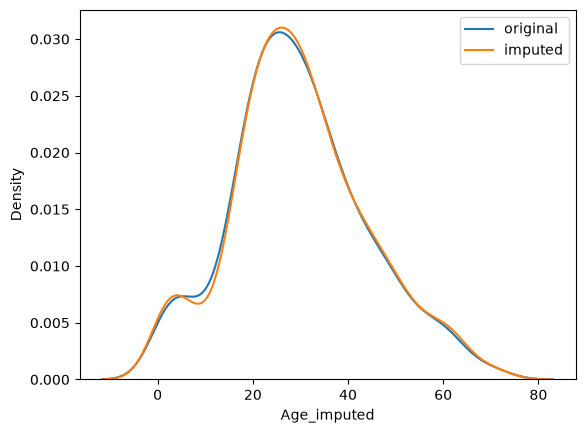

In [24]:
sns.distplot(X_train['Age'],label = 'original' , hist = False)
sns.distplot(X_train['Age_imputed'],label = 'imputed' , hist = False)

plt.legend()
plt.show()

In [27]:
print('original variance :' ,X_train['Age'].var())
print('imputed variance :', X_train['Age_imputed'].var())

original variance : 204.34951339046142
imputed variance : 207.51730559249512


In [28]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,62.489211
Age,71.512440,204.349513,204.349513
Age_imputed,62.489211,204.349513,207.517306


<Axes: >

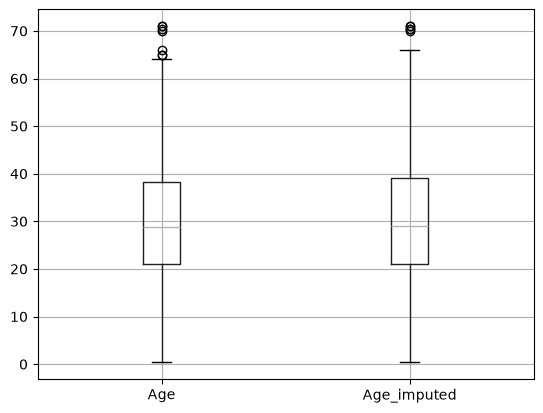

In [29]:
X_train[['Age','Age_imputed']].boxplot()

In [ ]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Series'